**What is Inference :** LLM inference is the process of using a trained language model to produce outputs from input text.

**Training** is nothing but process where model learn it's parameters 
**Inference** is process those learned parameters used to answer a prompt.


At a high level, inference is about one thing: given the tokens seen so far, predict the most likely next token, then repeat.

For example, if the input is:

"The capital of USA is"
the model computes probabilities over the vocabulary and may assign the highest probability to "Washington D,C". Then "Washington,D.C" is appended to the sequence, and the process repeats until a stopping condition is reached.

## 1.The inference pipeline

A typical LLM inference pipeline looks like this:

1. tokenization
2. embedding lookup
3. transformer forward pass
4. logits over vocabulary
5. sampling or decoding
6. next token
7. repeat until stop




**Tokenization**
The model does not directly process raw text. It processes tokens. A token may be a whole word, part of a word, punctuation, or whitespace pattern depending on the tokenizer.

For example:

"unbelievable" might become:
"un", "believ", "able"

or something similar depending on the tokenizer.

The length of the input in tokens matters a lot because computation and memory usage depend heavily on sequence length.



**Embedding**

**Each token ID is mapped to a vector of fixed size called the hidden size or model dimension.** If the model dimension is 4096, then each token becomes a 4096-dimensional vector.

If your prompt has 1000 tokens, the input tensor before entering the transformer stack is roughly:

1000 × 4096

ignoring the batch dimension for the moment.



**Transformer forward pass**

The embeddings pass through multiple transformer layers. Each layer usually contains:


**self-attention --> feed-forward network --> residual connections --> layer normalization**


During inference, the model processes the prompt and produces hidden states, then converts the hidden state of the last position into logits over the vocabulary.


**Logits and decoding**

**Logits:** Logits are the raw, unnormalized scores that the LLM outputs for every possible token (word or subword) in its vocabulary before converting them into probabilities.

The output of the model at each step is a vector of scores, one per vocabulary token. These scores are called logits.

Then a decoding strategy chooses the next token. Common choices are:

greedy decoding: choose the highest-probability token
sampling: randomly sample according to probabilities
top-k sampling: sample only from the top k tokens
top-p sampling: sample from the smallest set of tokens whose total probability exceeds p
beam search: keep several candidate sequences at once

Once the next token is selected, it is appended to the input and the process repeats.

This repeated generation is why inference is called autoregressive.

## 2. Prefill and decode  

A very important distinction in LLM inference is between the prefill phase and the decode phase.

**Prefill**

Prefill means forcing the model to start its response with specific text that you provide in advance, before it begins generating new tokens.

Instead of the model generating from a blank slate, you "prefill" part of the output with your desired content.

Prefill is the first pass over the prompt. If the user provides a prompt of 1000 tokens, the model must process all 1000 tokens to build the internal attention states.

This phase is relatively compute-heavy because the model handles the entire input sequence.


**Decode**

After the prompt is processed, generation begins one token at a time. For each newly generated token, the model computes the next output token.

This phase is iterative and often dominates user-visible response time because tokens are generated sequentially.









## 3. Why inference is expensive

LLM inference is expensive because modern models are very large and have to do many operations at every generated token.

The main costs come from:

reading billions of parameters from memory
running matrix multiplications across many layers
computing attention over the context
repeating this process for every output token

For a long conversation, the cost grows because the model must attend to more previous tokens unless optimization techniques are used.

That is where batching and KV cache become critical.

## 4. Batching

**Batching means processing multiple sequences together in one forward pass.**

Batching = Processing several prompts together in one forward pass to maximize efficiency and speed.

Instead of running the model separately for one request at a time, the server groups several requests into a batch and processes them simultaneously.

**Why batching helps**

Modern GPUs are designed for parallel math. They are much more efficient when working on larger blocks of data than when handling one tiny input at a time.

Suppose you have four user requests:

Request A: "Write a summary"
Request B: "Translate this paragraph"
Request C: "Explain recursion"
Request D: "Generate code"

Without batching, the GPU runs these four requests separately.

With batching, the server combines them into a single tensor with batch size 4 and processes them together.

This improves hardware utilization and raises throughput




### Batch dimension

If one sequence has shape:

Asequence_length × hidden_size

then a batch of B sequences has shape:

B × sequence_length × hidden_size

For example:

8 × 1000 × 4096

This means 8 requests, each 1000 tokens long, each token represented by 4096 numbers.



### Types of batching

There are two common types.

**Static batching**

The server waits for a fixed set of requests, then processes them together.

This is simple but can waste time if requests arrive unevenly.

**Dynamic batching**

The server continuously collects requests arriving within a short time window and groups them into a batch.

This is more efficient in production systems because traffic is not perfectly regular.

**Continuous batching**

Advanced LLM serving systems often use continuous batching, where requests at different generation stages are mixed together.

For example, while one request is in prefill, another may already be in decode. The scheduler tries to keep the GPU busy by merging work across requests.

This is more complex but usually gives much better throughput than naive batching



### Padding and variable lengths

A problem with batching is sequence with different lengths.

**Example:**

Request 1: 50 tokens
Request 2: 300 tokens
Request 3: 1000 tokens

To form a rectangular tensor, shorter sequences are padded to match the longest sequence. This can waste computation.

If the max length in a batch is 1000, then even the 50-token request may occupy space as if it were length 1000.

That is why batch construction matters. Good serving systems try to group similarly sized requests together.

### Benefits of batching

Batching improves:

GPU utilization
overall tokens per second
cost efficiency
number of users served at once

### Drawbacks of batching

Batching can worsen:

latency for individual users
padding waste
scheduler complexity
memory pressure

In practice, serving systems must balance batch size carefully.

## 5. KV cache

KV cache is one of the most important ideas in LLM inference.

To understand it, recall self-attention.

For each token, the model computes:

***Query, Key, Value***

In generation, when the model produces a new token, that token attends to all previous tokens.

Without KV cache, at every decode step the model would recompute Keys and Values for the entire previous context again and again. That would be extremely wasteful.

**What KV cache stores**

For each transformer layer, the system stores the Key and Value tensors for all previously processed tokens.

Then when a new token is generated:

the model computes Query for the new token
the model computes Key and Value only for the new token
the new Query attends to all stored previous Keys and Values plus the new one

This avoids recomputing old attention states

**Why it matters**

Suppose the prompt has 1000 tokens and the model has already generated 100 tokens.

Without KV cache, when generating token 101, the model might need to process all 1100 tokens again.

With KV cache, it only computes new work for the latest token while reusing stored attention information from the previous 1100 tokens.

This dramatically reduces computation during decode.


**Conceptual effect on cost**

Without KV cache:
each decode step redoes large parts of past work

With KV cache:
each decode step mostly does incremental work

This is why inference for autoregressive models is practical at all.



### What is stored per layer

If a model has:

L layers, H attention heads,sequence length T, head dimension D.

then the cache stores Keys and Values for each layer, each head, and each token position.

Very roughly, KV cache size grows with:

number of layers, number of heads, sequence length, batch size.

This is one reason long contexts consume so much memory.


### Trade-off of KV cache

KV cache improves speed but uses a lot of memory.

Longer prompts and larger batches mean larger caches.
Large models with many layers and heads need even more cache memory.

This creates a major engineering trade-off:

more context and more concurrency Vs more GPU memory consumption


**Example intuition**

Imagine the prompt:

"The cat sat on the"

The model processes it and stores Keys and Values for these tokens.

Now it predicts "mat".

At the next step, when predicting the next token after "mat", the model does not recompute full attention for every previous token from scratch. It reuses the stored Keys and Values for: "The","cat","sat","on","the","mat"

and **computes new attention only as needed for the latest position That is the core idea of KV cache.**




## 6. Latency versus throughput

These two terms are central in inference systems.

**Latency:** Latency is the time it takes for one request to get a response.

In LLMs, latency can mean different things:

time to first token,

time per output token,

time to full response 



**Time to first token**

This is how long the user waits before seeing the first generated token.

It includes:

request arrival, queueing, tokenization, prefill, first decode step

This is often the most noticeable measure for chat applications.


**Time per token**

After the first token appears, how quickly do the next tokens arrive.

Users experience this as the model's "typing speed."

**End-to-end latency**

The total time from submitting the prompt to receiving the complete response.

### Throughput
It is the volume of data an LLM system can process per unit of time, typically measured in tokens per second (TPS) or requests per second (RPS)

It can be measured as:

requests per second

tokens per second

generated tokens per second

prefill tokens per second

A high-throughput system can serve many users efficiently.

It's a measure of capacity, not speed—meaning a high-throughput system can handle many requests or tokens simultaneously, even if individual requests aren't the fastest.


#### The tension between them

Latency and throughput often pull in opposite directions.

**If you batch aggressively:**
1. You improve throughput
2. But some users wait longer for the batch to fill

**If you process each request immediately:**
1. You reduce latency
2. But the GPU may be underutilized, lowering throughput

This is one of the central trade-offs in production LLM serving.


**Example**

Suppose a GPU can process:

1 request alone in 50 ms

8 requests together in 120 ms

For a single user, 50 ms is better latency.

For the system, 8 requests in 120 ms is much better throughput than 8 separate runs of 50 ms each.

So production systems often aim for a compromise.

**In chat applications**

For interactive chat, low latency matters a lot.
Users care about fast time to first token and smooth streaming.

**In offline batch workloads**

For document summarization, embedding generation, or large-scale processing jobs, throughput matters more than individual latency.

In that case, large batches are often preferred.




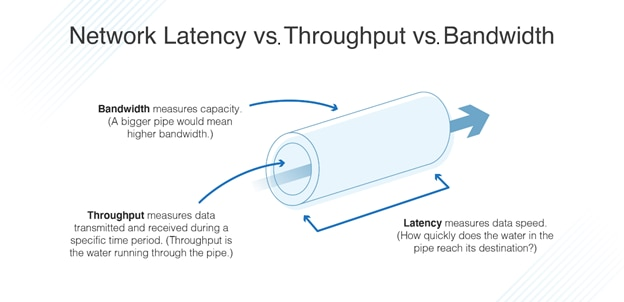
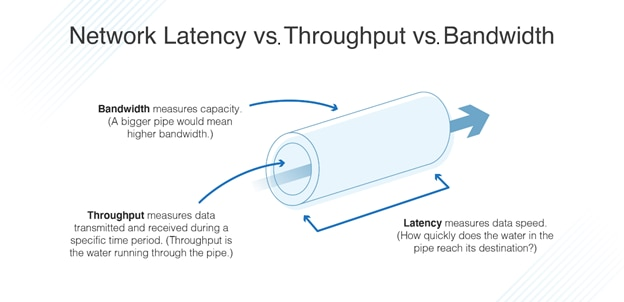

# 7.Why batching and KV cache interact

Batching and KV cache are not separate concerns. They strongly affect each other.

If you batch many ongoing generation requests together, each request has its own KV cache.
That means total memory use becomes:

sum of all requests' caches across all layers

As batch size grows, memory pressure can grow very quickly.

So a serving system must manage:

model weights
activations
KV caches
temporary buffers

all within the GPU memory budget.

This is why there is often a practical batch-size ceiling even if larger batches would improve throughput in theory.

# 8.Prompt length and output length

Inference cost depends on both input length and output length.

**Long prompt**

A long prompt increases prefill cost and KV cache size.

**Long output**

A long output increases decode time because the model must generate tokens one by one.

**Combined effect**

A request with a 10,000-token prompt and a 2000-token response is much more expensive than one with a 100-token prompt and a 50-token response.

This matters for capacity planning and cost estimation.

# 9. Memory-bound versus compute-bound behavior

Another important concept in inference is whether performance is limited by compute or memory.

**Compute-bound**

A workload is compute-bound when the GPU spends most of its time doing arithmetic.

Prefill often leans more in this direction because it involves large matrix multiplications across the prompt.

**Memory-bound**

A workload is memory-bound when speed is limited more by moving data than by arithmetic.

Decode often becomes memory-bound because each generated token requires repeatedly reading model weights and cache data, even though the amount of fresh computation per step is small.

This is why decode can be surprisingly slow compared with prefill.

# 10. Time to first token and token generation speed

In user-facing systems, two metrics matter a lot:

**Time to first token**

This reflects how quickly the system starts responding.

A long prompt hurts this because prefill must finish before the first token is generated.

**Tokens per second**

This reflects how fast the response streams after it starts.

KV cache helps tokens per second a lot because it reduces repeated work during decode.

A system can have a decent token generation speed but poor time to first token if prefill is slow.

# 11. Common inference optimizations

Beyond batching and KV cache, several other techniques are used.

**Quantization**

Weights are stored in lower precision, such as 8-bit or 4-bit instead of 16-bit or 32-bit.

Benefits:
less memory use
faster memory transfer
sometimes faster inference

Trade-off:
possible quality loss if quantization is too aggressive

**Tensor parallelism**

The model is split across multiple GPUs so one large inference request can run on hardware that cannot fit the full model on a single device.

**Pipeline parallelism**

Different groups of layers are placed on different GPUs, and tokens move through the pipeline.

**Speculative decoding**

A smaller draft model proposes several tokens, and the larger model verifies them. This can reduce latency in some settings.

**Prefix caching**

If many requests share the same prompt prefix, the system can reuse precomputed states for that prefix.

**Flash attention and optimized kernels**

Specialized GPU kernels reduce memory movement and make attention faster.

# 12. Practical view of one chat request

Let’s walk through a single request in production.

User input:
"Explain batching, KV cache, and latency versus throughput."

**Step 1: tokenization**

The input text is broken into tokens.

**Step 2: queueing**

The request may wait briefly so the scheduler can build a batch.

**Step 3: prefill**

The prompt tokens are processed through all transformer layers.
Keys and Values for the prompt are stored in the KV cache.

**Step 4: first decode step**

The model computes logits for the next token.
A decoding rule selects the first output token.

**Step 5: repeated decode**

Each new token uses the KV cache from previous tokens.
The model generates one token at a time until completion.

**Step 6: detokenization**

Generated token IDs are turned back into readable text.

**Step 7: streaming**

The system may stream tokens to the user as they are generated.

This whole path is what people usually mean by LLM inference.

# 13. Why LLM inference is different from classical model inference

In many traditional machine learning models, inference is a single forward pass:

input
→ model
→ output

For autoregressive LLMs, inference is more complex because generation is sequential:

prompt
→ prefill
→ token 1
→ token 2
→ token 3
→ and so on

This sequential nature makes latency optimization much more important.

It also means a user’s response time depends not only on model size, but also on:

* prompt length
* output length
* batch size
* cache size
* scheduler policy
* decoding method

# 14. Simple intuition for the three topics

### Batching

Batching is like serving many customers at once in a cafeteria kitchen instead of cooking one plate from start to finish before starting the next.
It improves efficiency, but one customer may wait a little longer before cooking begins.

### KV cache

KV cache is like taking notes during a meeting so you do not have to replay the entire conversation every time a new person speaks.
You keep the important previous information and only process the new addition.

### Latency versus throughput

Latency is how long one customer waits.
Throughput is how many customers the kitchen serves per hour.
Trying to maximize one can hurt the other.

# 15. Summary

* LLM inference is the process of generating text from a trained model by repeatedly predicting the next token.

* The core stages are tokenization, embedding, transformer forward pass, logits, decoding, and repetition.

1. Two phases matter:

**prefill,** where the model processes the prompt 

**decode**, where the model generates tokens one by one

* Batching improves hardware utilization and total system capacity by processing multiple requests together, but it can increase waiting time for individual users.

* KV cache stores previously computed Keys and Values for attention so the model does not recompute old context during generation. This greatly speeds up decode, but it increases memory usage.

**Latency** is the response time for an individual request.

**Throughput** is the amount of total work the system can do over time.

A practical inference system is mostly an exercise in balancing these trade-offs:

1. fast user response
2. high server efficiency
3. limited GPU memory
4. variable request lengths
5. large model size